# Regression — Review 1

## 1. Import Libraries

In [167]:
# CELL 1: Setup & Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=" * 60)
print("REGRESSION MODEL — SETUP")
print("=" * 60)
print("All required libraries imported successfully.")
print(f"Random state: {RANDOM_STATE}")
print("=" * 60)

REGRESSION MODEL — SETUP
All required libraries imported successfully.
Random state: 42


In [168]:
# CELL 2: Load Dataset

DATA_PATH = "../data/diabetes_prediction_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DATASET LOADING")
print("=" * 60)
print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print("=" * 60)

DATASET LOADING
Dataset loaded successfully.
Rows    : 100,000
Columns : 9


In [169]:
# CELL 3: Initial Data Preview

print("=" * 60)
print("INITIAL DATA PREVIEW")
print("=" * 60)

display(df.head())

print("\nFirst 5 records displayed successfully.")

INITIAL DATA PREVIEW


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



First 5 records displayed successfully.


In [170]:
# CELL 4: Dataset Structure

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

print(f"\nDataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

print("\nData types:")
display(df.dtypes.rename("Data Type").to_frame())

print("=" * 60)

DATASET STRUCTURE

Dataset shape : 100,000 rows × 9 columns

Column names:
 1. gender
 2. age
 3. hypertension
 4. heart_disease
 5. smoking_history
 6. bmi
 7. HbA1c_level
 8. blood_glucose_level
 9. diabetes

Data types:


,Data Type
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [171]:
# CELL 5: Missing Value Analysis

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2)
})

print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

display(missing)

total_missing = df.isnull().sum().sum()

print(f"\nTotal missing values: {total_missing:,}")

if total_missing == 0:
    print("No missing values detected.")
else:
    print("Missing values detected. Further treatment is required.")

print("=" * 60)

MISSING VALUE ANALYSIS


,Missing Values,Missing (%)
gender,0,0.0
age,0,0.0
hypertension,0,0.0
heart_disease,0,0.0
smoking_history,0,0.0
bmi,0,0.0
HbA1c_level,0,0.0
blood_glucose_level,0,0.0
diabetes,0,0.0



Total missing values: 0
No missing values detected.


In [172]:
# CELL 6: Duplicate Record Analysis

duplicate_count = df.duplicated().sum()

print("=" * 60)
print("DUPLICATE RECORD ANALYSIS")
print("=" * 60)

print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count == 0:
    print("No duplicate records detected.")
else:
    print("Duplicate records detected.")

print("=" * 60)

DUPLICATE RECORD ANALYSIS
Duplicate rows: 3,854
Duplicate records detected.


In [173]:
# CELL 7: Descriptive Statistics

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df.describe().T.round(2))

print("=" * 60)

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.89,22.52,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.07,0.26,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.04,0.19,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.32,6.64,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.53,1.07,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.06,40.71,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.08,0.28,0.00,0.00,0.00,0.00,1.00


In [174]:
# CELL 8: Categorical Feature Analysis

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("=" * 60)
print("CATEGORICAL FEATURE ANALYSIS")
print("=" * 60)

print(f"Categorical features: {len(categorical_columns)}")

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * 40)
    display(df[column].value_counts(dropna=False).to_frame("Count"))

print("=" * 60)

CATEGORICAL FEATURE ANALYSIS
Categorical features: 2

gender
----------------------------------------


,Count
gender,
Female,58552
Male,41430
Other,18



smoking_history
----------------------------------------


,Count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


NUMERICAL FEATURE DISTRIBUTIONS


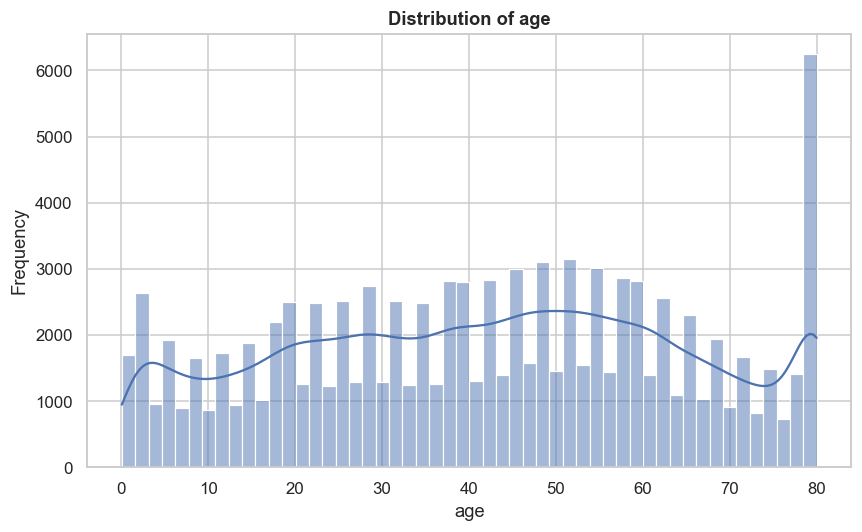

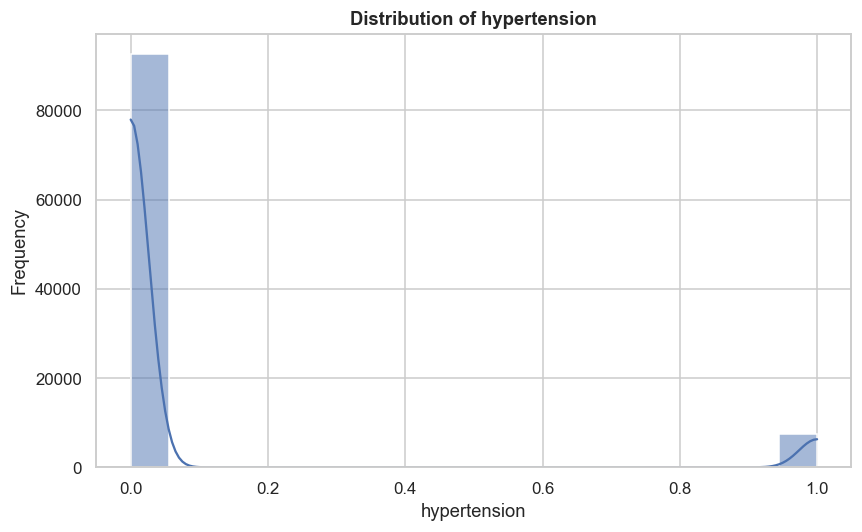

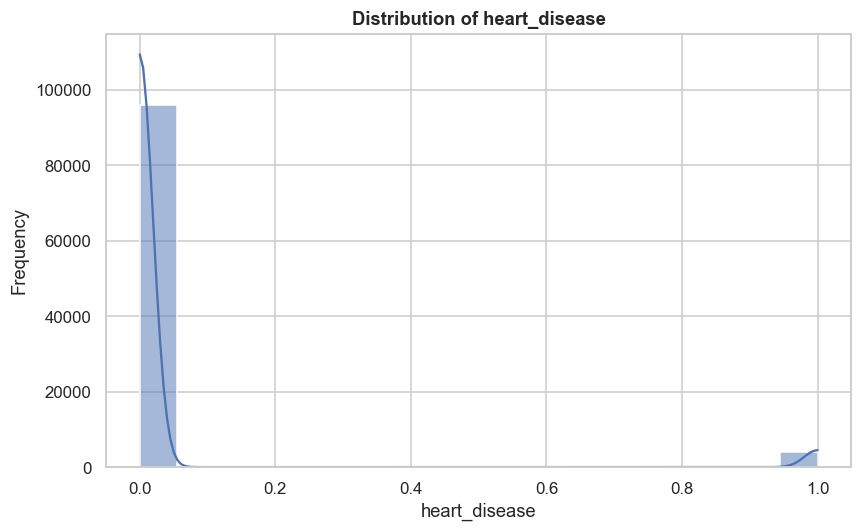

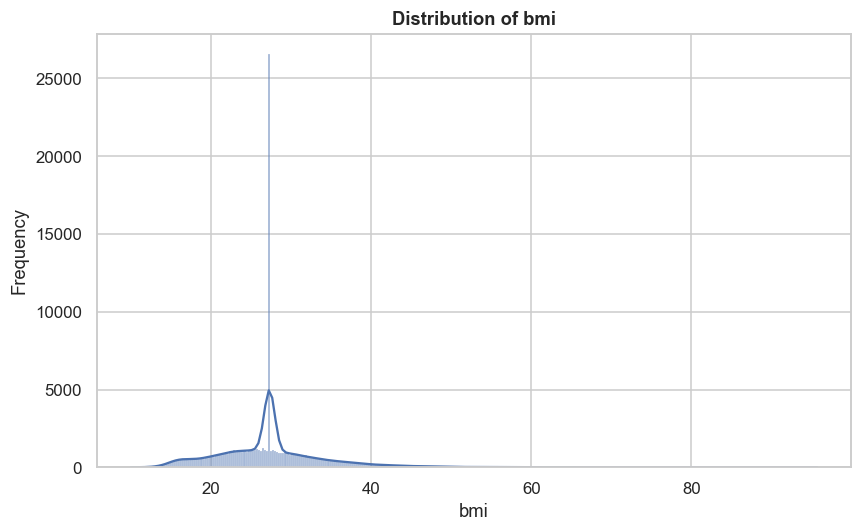

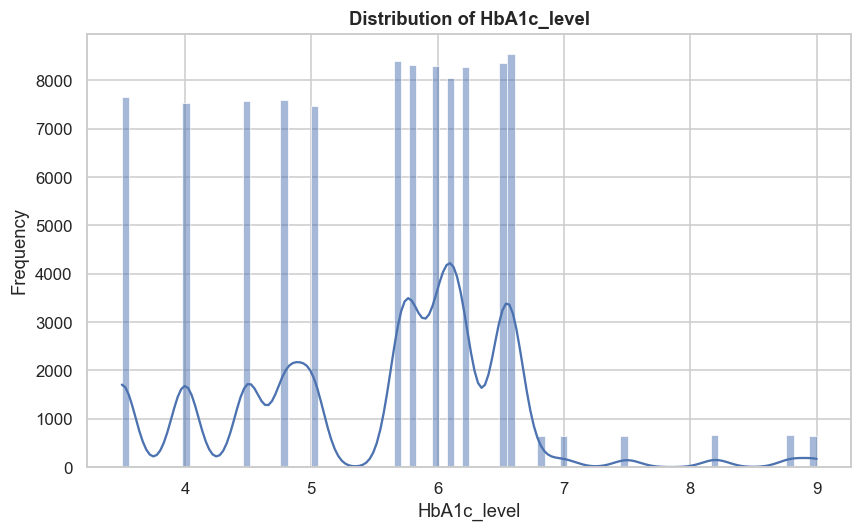

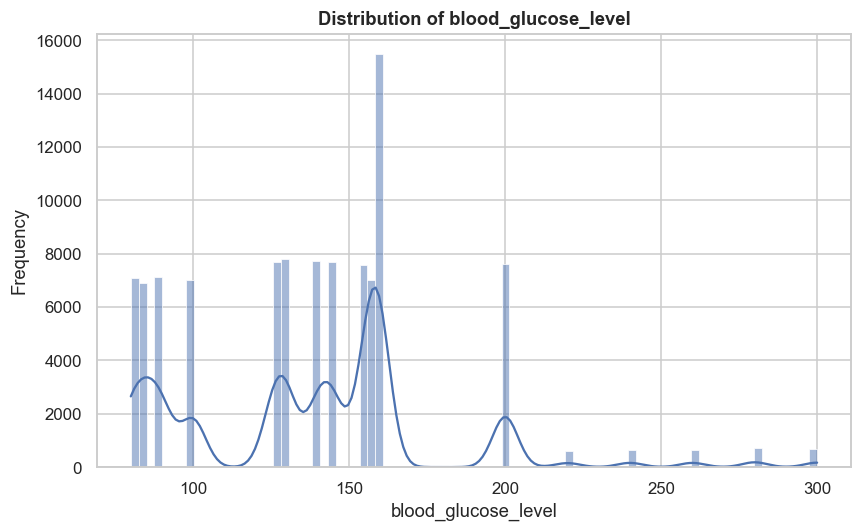

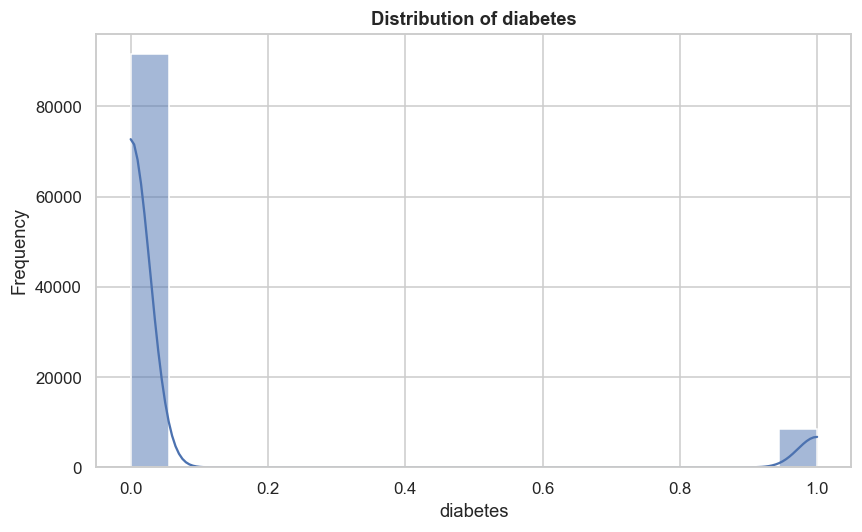

In [175]:
# CELL 9: Numerical Feature Distributions

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("=" * 60)
print("NUMERICAL FEATURE DISTRIBUTIONS")
print("=" * 60)

for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

print("=" * 60)

CATEGORICAL FEATURE DISTRIBUTIONS


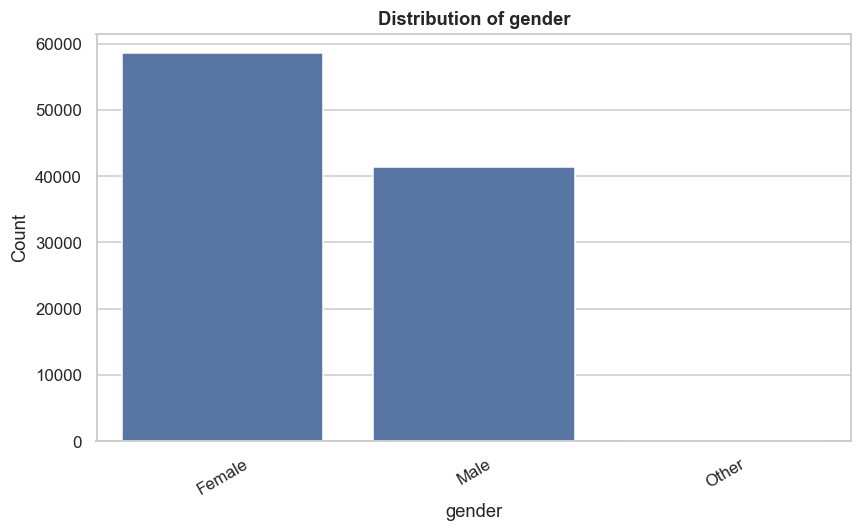

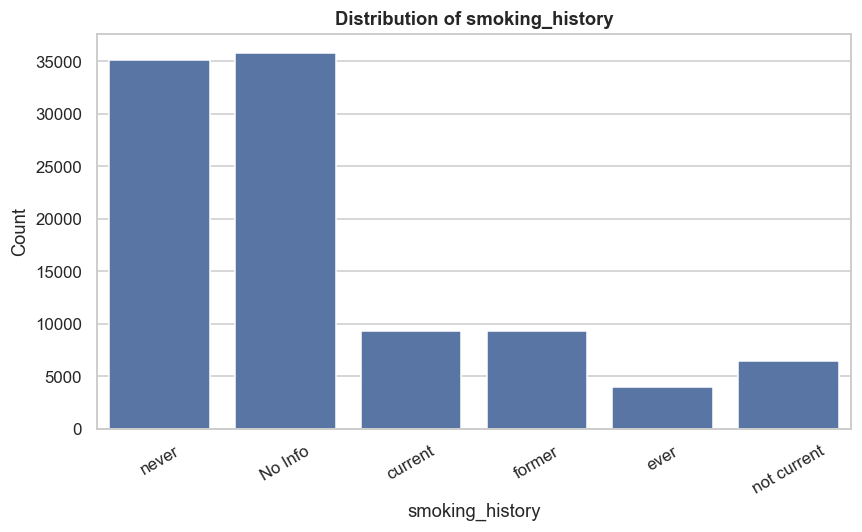

In [176]:
# CELL 10: Categorical Feature Distributions

print("=" * 60)
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("=" * 60)

for column in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=column)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

print("=" * 60)

CORRELATION HEATMAP


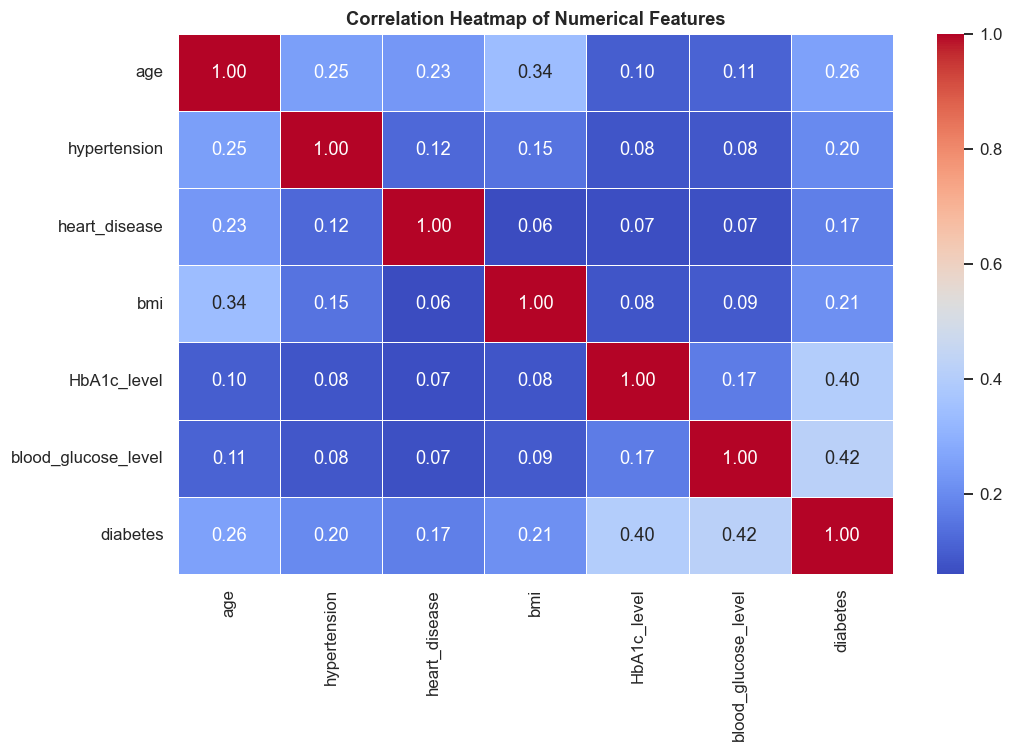

In [177]:
# CELL 11: Correlation Heatmap

print("=" * 60)
print("CORRELATION HEATMAP")
print("=" * 60)

correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

print("=" * 60)

CANDIDATE TARGET DISTRIBUTIONS


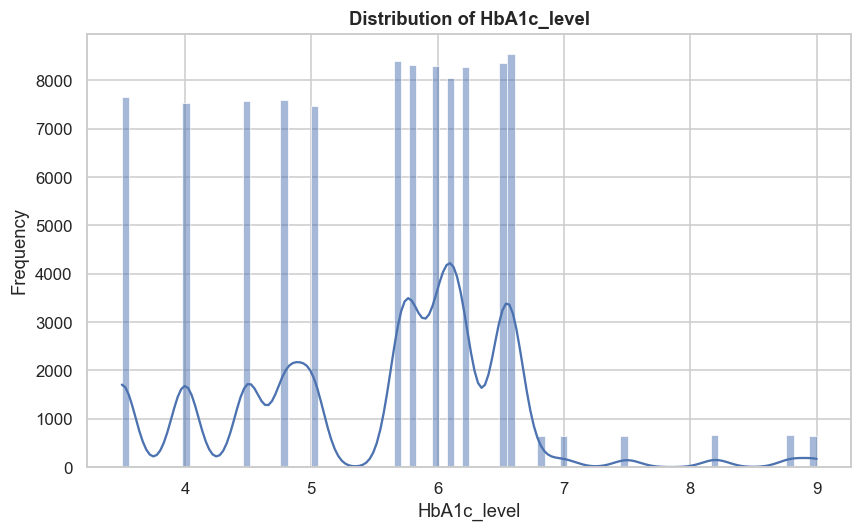

HbA1c_level statistics:
count    100000.00
mean          5.53
std           1.07
min           3.50
25%           4.80
50%           5.80
75%           6.20
max           9.00
Name: HbA1c_level, dtype: float64
------------------------------------------------------------


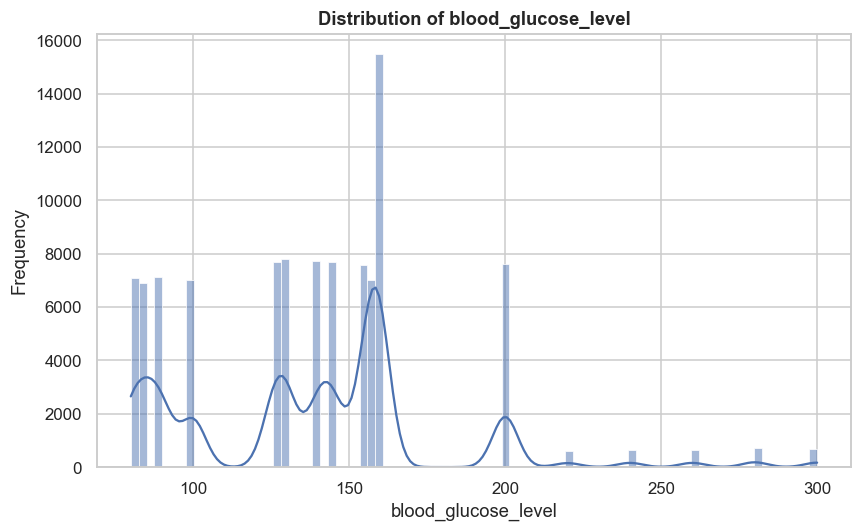

blood_glucose_level statistics:
count    100000.00
mean        138.06
std          40.71
min          80.00
25%         100.00
50%         140.00
75%         159.00
max         300.00
Name: blood_glucose_level, dtype: float64
------------------------------------------------------------


In [178]:
# CELL 12: Candidate Target Distributions

target_candidates = ["HbA1c_level", "blood_glucose_level"]

print("=" * 60)
print("CANDIDATE TARGET DISTRIBUTIONS")
print("=" * 60)

for column in target_candidates:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    print(f"{column} statistics:")
    print(df[column].describe().round(2))
    print("-" * 60)

print("=" * 60)

REGRESSION TARGET
Selected target: blood_glucose_level

Feature 1: age
Feature 2: bmi


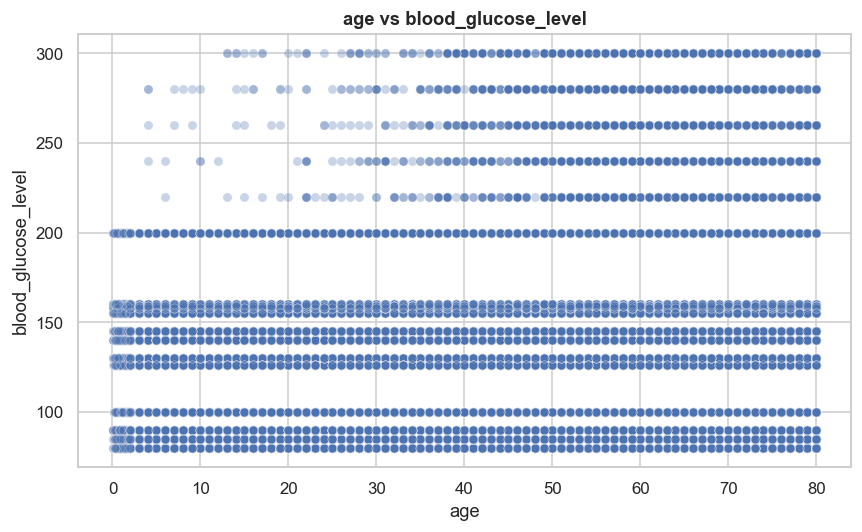

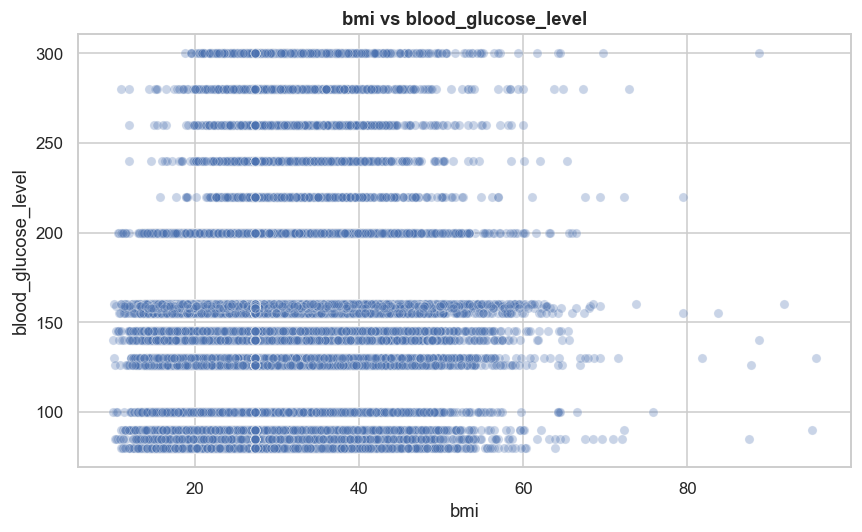

In [179]:
# CELL 13: Regression Target and Feature-Target Relationships

# Set the regression target chosen by the team
target_column = "blood_glucose_level"

print("=" * 60)
print("REGRESSION TARGET")
print("=" * 60)
print(f"Selected target: {target_column}")

# Select two numerical features for visualization
feature_1 = "age"
feature_2 = "bmi"

print(f"\nFeature 1: {feature_1}")
print(f"Feature 2: {feature_2}")

print("=" * 60)

# Feature 1 vs Target
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x=feature_1,
    y=target_column,
    alpha=0.3
)
plt.title(f"{feature_1} vs {target_column}")
plt.xlabel(feature_1)
plt.ylabel(target_column)
plt.tight_layout()
plt.show()

# Feature 2 vs Target
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x=feature_2,
    y=target_column,
    alpha=0.3
)
plt.title(f"{feature_2} vs {target_column}")
plt.xlabel(feature_2)
plt.ylabel(target_column)
plt.tight_layout()
plt.show()

print("=" * 60)

In [180]:
# CELL 14: Data Cleaning Check

print("=" * 60)
print("DATA CLEANING CHECK")
print("=" * 60)

# Missing values
missing_values = df.isnull().sum().sum()

# Duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Total missing values : {missing_values:,}")
print(f"Duplicate rows       : {duplicate_rows:,}")

# Numerical columns for outlier inspection
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nPotential outliers using IQR method:")
print("-" * 60)

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": column,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": int(outlier_count)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

print("=" * 60)

DATA CLEANING CHECK
Total missing values : 0
Duplicate rows       : 3,854

Potential outliers using IQR method:
------------------------------------------------------------


,Feature,Lower Bound,Upper Bound,Outlier Count
0,age,-30.0,114.0,0
1,hypertension,0.0,0.0,7485
2,heart_disease,0.0,0.0,3942
3,bmi,14.7,38.5,7086
4,HbA1c_level,2.7,8.3,1315
5,blood_glucose_level,11.5,247.5,2038
6,diabetes,0.0,0.0,8500


In [181]:
# CELL 15: Data Cleaning

print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

# Remove duplicate rows
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
duplicates_removed = rows_before - rows_after

print(f"Rows before removing duplicates : {rows_before:,}")
print(f"Duplicate rows removed          : {duplicates_removed:,}")
print(f"Rows after removing duplicates  : {rows_after:,}")

# Check missing values again
remaining_missing = df.isnull().sum().sum()

print(f"\nRemaining missing values        : {remaining_missing:,}")

if remaining_missing == 0:
    print("No missing values remain.")

# Outlier decision
print("\nOutlier treatment:")
print("- Binary variables are not treated as outliers.")
print("- Valid extreme numerical observations are retained.")
print("- No arbitrary outlier deletion or clipping is applied.")

print("=" * 60)

DATA CLEANING
Rows before removing duplicates : 100,000
Duplicate rows removed          : 3,854
Rows after removing duplicates  : 96,146

Remaining missing values        : 0
No missing values remain.

Outlier treatment:
- Binary variables are not treated as outliers.
- Valid extreme numerical observations are retained.
- No arbitrary outlier deletion or clipping is applied.


In [182]:
# CELL 16: Feature Engineering

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Create an interaction feature between age and BMI
df["age_bmi_interaction"] = df["age"] * df["bmi"]

print("New feature created:")
print("age_bmi_interaction = age × bmi")

print("\nUpdated dataset shape:")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nPreview of the engineered feature:")
display(
    df[["age", "bmi", "age_bmi_interaction"]].head()
)

print("=" * 60)

FEATURE ENGINEERING
New feature created:
age_bmi_interaction = age × bmi

Updated dataset shape:
Rows    : 96,146
Columns : 10

Preview of the engineered feature:


,age,bmi,age_bmi_interaction
0,80.0,25.19,2015.20
1,54.0,27.32,1475.28
2,28.0,27.32,764.96
3,36.0,23.45,844.20
4,76.0,20.14,1530.64


In [183]:
# CELL 17: Target Selection and Train-Test Split

print("=" * 60)
print("TARGET SELECTION AND TRAIN-TEST SPLIT")
print("=" * 60)

# Regression target
target_column = "blood_glucose_level"

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Target variable: {target_column}")
print(f"Number of features: {X.shape[1]}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("\nTrain-test split:")
print(f"Training samples   : {X_train.shape[0]:,}")
print(f"Testing samples    : {X_test.shape[0]:,}")
print(f"Training features  : {X_train.shape[1]}")
print(f"Testing features   : {X_test.shape[1]}")

print("\nSplit ratio:")
print(f"Training: {len(X_train) / len(X) * 100:.0f}%")
print(f"Testing : {len(X_test) / len(X) * 100:.0f}%")

print("=" * 60)

TARGET SELECTION AND TRAIN-TEST SPLIT
Target variable: blood_glucose_level
Number of features: 9

Train-test split:
Training samples   : 76,916
Testing samples    : 19,230
Training features  : 9
Testing features   : 9

Split ratio:
Training: 80%
Testing : 20%


In [184]:
# CELL 18: Encoding and Scaling

print("=" * 60)
print("ENCODING AND SCALING")
print("=" * 60)

# Identify categorical and numerical features
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(f"Categorical features: {categorical_features}")
print(f"Numerical features  : {numerical_features}")

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nPreprocessing completed successfully.")

print(f"Original training shape : {X_train.shape}")
print(f"Processed training shape: {X_train_processed.shape}")

print(f"\nOriginal testing shape  : {X_test.shape}")
print(f"Processed testing shape : {X_test_processed.shape}")

print("\nEncoding and scaling were fitted only on the training data.")
print("=" * 60)

ENCODING AND SCALING
Categorical features: ['gender', 'smoking_history']
Numerical features  : ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'diabetes', 'age_bmi_interaction']

Preprocessing completed successfully.
Original training shape : (76916, 9)
Processed training shape: (76916, 16)

Original testing shape  : (19230, 9)
Processed testing shape : (19230, 16)

Encoding and scaling were fitted only on the training data.
